In [3]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import(classification_report, confusion_matrix, roc_auc_score, roc_curve)
tf.random.set_seed(42)
np.random.seed(42)
# import seaborn as sns

In [4]:
train_df = pd.read_csv("diabetes_train.csv")
val_df = pd.read_csv('diabetes_val.csv')
test_df = pd.read_csv("diabetes_test.csv")

X_train = train_df.drop(columns=['Outcome']).values.astype(np.float32)
y_train = train_df['Outcome'].values.astype(np.float32)

X_val = val_df.drop(columns=['Outcome']).values.astype(np.float32)
y_val = val_df['Outcome'].values.astype(np.float32)

X_test = test_df.drop(columns=['Outcome']).values.astype(np.float32)
y_test = test_df['Outcome'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f" Val: {X_val.shape}")
print(f" Test: {X_test.shape}")

print(f" number of features: {X_train.shape[1]}")


Train: (537, 14)
 Val: (115, 14)
 Test: (116, 14)
 number of features: 14


In [5]:
with open("diabetes_metadata.json") as f:
    metadata = json.load(f)
feature_cols = metadata['feature_cols']
train_medians = metadata['train_medians']
scaler_mean = np.array(metadata['scaler_mean'], dtype = np.float32)
scaler_Scale = np.array(metadata['scaler_scale'], dtype=np.float32)

print(f"Loaded metadata  for {len(feature_cols)} features")
scaler_Scale

Loaded metadata  for 14 features


array([3.3820171e+00, 2.9510159e+01, 1.2327506e+01, 9.1778965e+00,
       8.1450020e+01, 6.6842527e+00, 3.2427591e-01, 1.1811565e+01,
       1.3876493e+03, 4.3319400e+02, 4.3056646e-01, 4.8798811e-01,
       4.8535880e-01, 4.5137453e-01], dtype=float32)

In [6]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name="features")

    X= keras.layers.Dense(128, kernel_regularizer = keras.regularizers.l2(1e-4))(inputs)
    X= keras.layers.BatchNormalization()(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.3)(X)


    X= keras.layers.Dense(64, kernel_regularizer = keras.regularizers.l2(1e-4))(X)
    X= keras.layers.BatchNormalization()(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.3)(X)

    X= keras.layers.Dense(32)(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.2)(X)

    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(X)
    return keras.Model(inputs, outputs, name="DiabetesANN")

In [7]:
model = build_ann(X_train.shape[1])
model.summary()

Model: "DiabetesANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 14)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss = 'binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=25,
        
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=10,
        min_lr=1e-6, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_malaria_model.keras", monitor="val_loss",
        save_best_only = True, mode='max', verbose=0
    ),
]
history = model.fit(
    X_train, y_train,
    epochs = 300, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks = callbacks, verbose=1,
)
print(f"\nEpochs run: {len(history.history['loss'])}")
print(f"best val AUC: {max(history.history['val_loss']):.4f}")

Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.4842 - auc: 0.5937 - loss: 0.7975 - precision: 0.3832 - recall: 0.7766 - val_accuracy: 0.6957 - val_auc: 0.7603 - val_loss: 0.6564 - val_precision: 0.5641 - val_recall: 0.5500 - learning_rate: 5.0000e-04
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5940 - auc: 0.6316 - loss: 0.6942 - precision: 0.4423 - recall: 0.6117 - val_accuracy: 0.8000 - val_auc: 0.8348 - val_loss: 0.5978 - val_precision: 0.7429 - val_recall: 0.6500 - learning_rate: 5.0000e-04
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7095 - auc: 0.7684 - loss: 0.5729 - precision: 0.5816 - recall: 0.6064 - val_accuracy: 0.8000 - val_auc: 0.8408 - val_loss: 0.5588 - val_precision: 0.7429 - val_recall: 0.6500 - learning_rate: 5.0000e-04
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7300 - auc: 0.7867 - loss: 0.5437 - precision: 0.6272 - recall: 0.5638 - val_accuracy: 0.8000 - val_auc: 0.8470 - val_loss: 

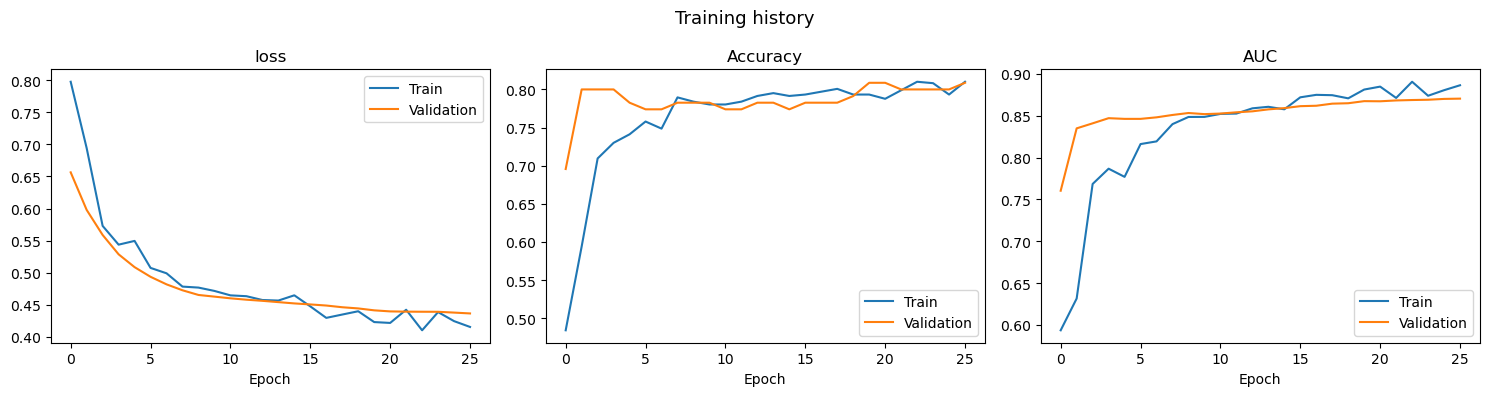

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history.history["loss"], label='Train')
axes[0].plot(history.history["val_loss"], label='Validation')
axes[0].set_title("loss")
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history["accuracy"], label='Train')
axes[1].plot(history.history["val_accuracy"], label='Validation')
axes[1].set_title("Accuracy")
axes[1].set_xlabel('Epoch')
axes[1].legend()

# axes[2].scatter(y_test, y_pred, alpha=0.3, s=5, color="steelblue")
axes[2].plot(history.history['auc'],  label='Train')
axes[2].plot(history.history['val_auc'],  label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_title('AUC')
axes[2].legend()

plt.suptitle('Training history', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
model.load_weights('best_diabetes.keras')
test_results = model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")

loss        : 0.4233
compile_metrics: 0.8362


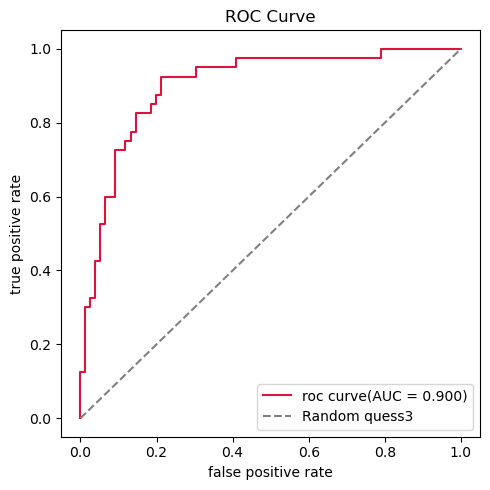

ROC-AUC: 0.9003


In [12]:
y_prob = model.predict(X_test, verbose = 0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize = (5, 5))
plt.plot(fpr, tpr, color='crimson', label=f'roc curve(AUC = {auc_score:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--', label="Random quess3")
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC-AUC: {auc_score:.4f}')

              precision    recall  f1-score   support

 No Diabetes       0.88      0.87      0.87        76
    Diabetes       0.76      0.78      0.77        40

    accuracy                           0.84       116
   macro avg       0.82      0.82      0.82       116
weighted avg       0.84      0.84      0.84       116



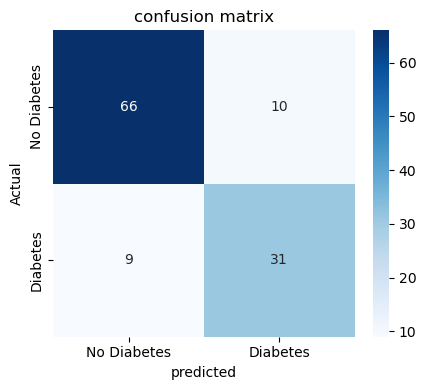

In [13]:
y_pred = (y_prob >= 0.5).astype(int)
from sklearn.preprocessing import StandardScaler
import seaborn as sns

print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Diabetes', 'Diabetes'],
           yticklabels=['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.xlabel('predicted')
plt.title("confusion matrix")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches = 'tight')
plt.show()

In [47]:
model.save('diabetes_ann.keras')
with open('diabetes_inference_kit.pkl', 'wb') as f:
    pickle.dump({
        'scaler_mean': scaler_mean,
        'scaler_scale': scaler_Scale,
        'feature_cols': feature_cols,
        'train_medians': train_medians,
    }, f)
print('saved diabetes_ann.keras')
print('saved diabetes_inference_kit.pkl')

saved diabetes_ann.keras
saved diabetes_inference_kit.pkl


In [2]:
def predict_patient(patient, model, feature_cols, scaler_mean,scaler_Scale):
    patient = patient.copy()

    patient['Glucose_x_BMI'] = patient['Glucose'] * patient['BMI']
    patient['Age_x_BMI'] = patient['Age'] * patient['BMI']
    patient['impaired_glucose'] =float(patient['Glucose'] >= 100)
    patient['diabetic_glucose'] =float(patient['Glucose'] >= 126)
    patient['is_obese'] =float(patient['BMI']>= 30)
    patient['older_patient'] =float(patient['Age'] >= 40)

    row = np.array([patient[col] for col in feature_cols], dtype=np.float32)

    row_scaled = (row - scaler_mean)/ scaler_Scale
    row_scaled = row_scaled.reshape(1, -1)

    probability = model.predict( row_scaled, verbose=0)[0][0]
    prediction = 'Diabetes' if probability >= 0.5 else 'no Diabetes'

    print(f' probability of diabetes: {probability: .1%}')
    print(f"prediction: {prediction}")

In [60]:
patient_1 = {
    'Pregnancies':6, 'Glucose':148, 'BloodPressure': 72, 'SkinThickness': 35,
    'Insulin': 0, 'BMI':33.6, 'DiabetesPedigreeFunction':0.627, 'Age':50,
}
print('patient 1 (actual: Diabetes)')
predict_patient(patient_1, model, feature_cols, scaler_mean, scaler_Scale)

print()
patient_2 = {
    'Pregnancies':1, 'Glucose':85, 'BloodPressure': 66, 'SkinThickness':29,
    'Insulin':0, 'BMI':26.6, 'DiabetesPedigreeFunction':0.351, 'Age':31,
}
print("patient 2 (actual: No Diabetes)")
predict_patient(patient_2, model, feature_cols, scaler_mean, scaler_Scale)

patient 1 (actual: Diabetes)
 probability of diabetes:  0.1%
prediction: no Diabetes

patient 2 (actual: No Diabetes)
 probability of diabetes:  0.0%
prediction: no Diabetes
